In [ ]:
import os
try:
  from google.colab import drive
  drive.mount('/content/drive')
  os.chdir("/content/drive/MyDrive/COMP530-Project")
except ImportError:
  os.chdir("../data/processed")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
import pandas as pd
df = pd.read_csv(
    "AWID3_Parsed/Disass.csv",
    escapechar='\\',
    low_memory=False,
    skiprows=range(1, 1400000),
    # nrows=500000
    )

In [4]:
desc_df = df.describe().T
filtered_df = desc_df[
    (desc_df['count'] >= 300000.0) &
    (desc_df['std'] > 0)
     ]
sorted_df = filtered_df.sort_values(by='std')
display(sorted_df)

,count,mean,std,min,25%,50%,75%,max
frame.time_delta_displayed,613720.0,3.025164e-04,1.974943e-03,0.000000e+00,4.000000e-05,6.300000e-05,1.480000e-04,1.702840e-01
frame.time_delta,613720.0,3.025164e-04,1.974943e-03,0.000000e+00,4.000000e-05,6.300000e-05,1.480000e-04,1.702840e-01
wlan.fc.type,613720.0,9.567229e-01,7.055740e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
wlan_radio.phy,613720.0,5.669931e+00,1.248534e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,8.000000e+00
wlan.fc.subtype,613720.0,1.082985e+01,2.205296e+00,0.000000e+00,9.000000e+00,1.100000e+01,1.300000e+01,1.400000e+01
radiotap.length,613720.0,5.771252e+01,3.302288e+00,4.800000e+01,5.600000e+01,5.600000e+01,5.600000e+01,6.400000e+01
radiotap.datarate,477110.0,1.244952e+01,9.658521e+00,6.000000e+00,6.000000e+00,6.000000e+00,2.400000e+01,7.222222e+01
wlan_radio.signal_dbm,613720.0,-4.744601e+01,1.231369e+01,-8.100000e+01,-5.600000e+01,-4.000000e+01,-3.600000e+01,-2.800000e+01
frame.time_relative,613720.0,4.996486e+02,4.867865e+01,4.180102e+02,4.592357e+02,5.009722e+02,5.261846e+02,6.036703e+02
frame.time_epoch,613720.0,1.608310e+09,4.867865e+01,1.608310e+09,1.608310e+09,1.608310e+09,1.608310e+09,1.608310e+09


In [9]:
import numpy as np

condition = (
    ((df['wlan.fc.subtype'] == 10) | (df['wlan.fc.subtype'] == 12)) &
    (df['wlan.fc.protected'] == 0) &
    ((df['frame.number'] >= 1404237) & (df['frame.number'] <= 2013346))
)

df['label'] = np.where(condition, 'disass', 'normal')

# Display the count of each label to verify
display(df['label'].value_counts())

,count
label,
normal,486273
disass,127447


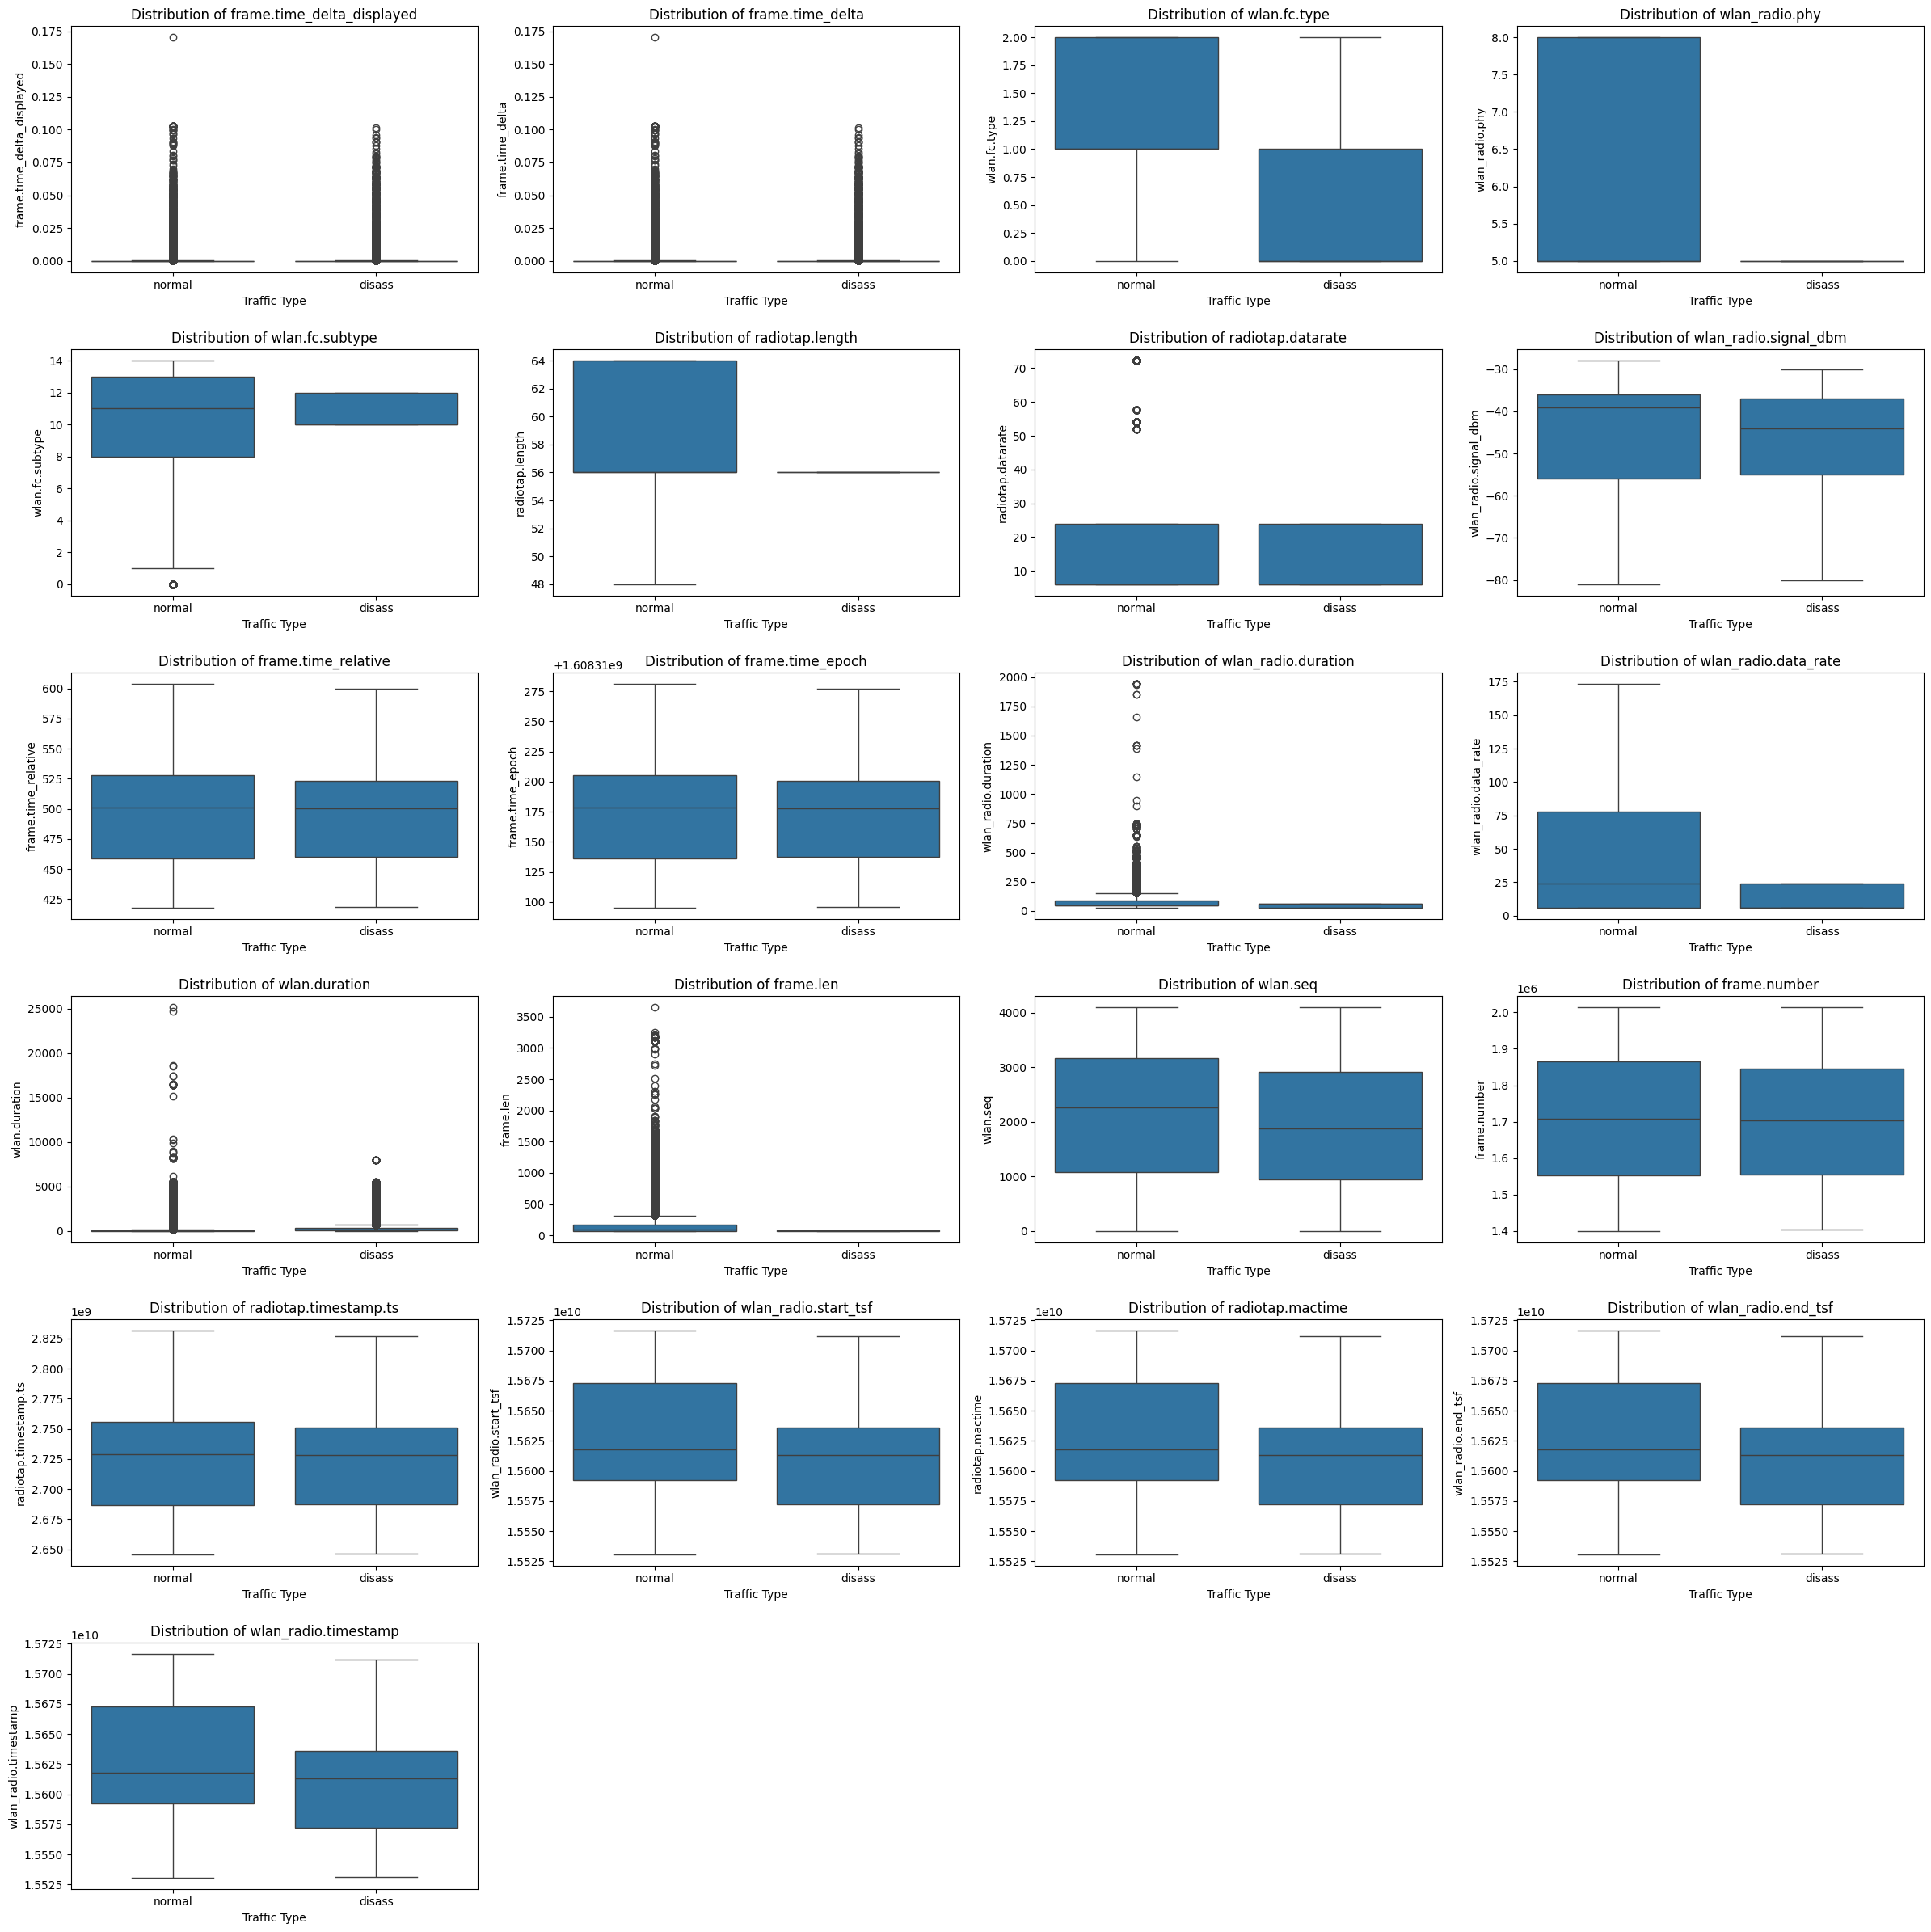

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of columns to plot from the index of sorted_df
columns_to_plot = sorted_df.index.tolist()

# Determine grid dimensions for subplots
num_columns = len(columns_to_plot)
num_cols_grid = 4  # Adjust as needed
num_rows_grid = (num_columns + num_cols_grid - 1) // num_cols_grid

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(num_cols_grid * 6, num_rows_grid * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(columns_to_plot):
    sns.boxplot(x='label', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Traffic Type')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()